# Función de Correlación a dos puntos ($\mathbb{R}$)

Es convencional expresar la temperatura observada y predecida del CMB como expansión de armónicos esféricos, de la forma:


$$
    T(\theta, \, \phi) = \sum_{l=0}^\infty \, \sum_{m = -\ell}^\ell \, a_{lm}\,\mathrm{Y}_{lm}(\theta,\, \phi) \tag{1}
$$

El primer término correspondiente a $\ell = 0$ representa la temperatura media, mientras que $\ell \geq 1$ representan las anisotropías en la temperatura, $\Delta T (\theta, \, \phi)$. El término $\ell = 1$ está dominado por una gran contribución "Doppler" debida a nuestro movimiento relativo respecto a algunos marcos del resto.

Nosotros nos centraremos entonces en los términos relevantes $\ell \geq 2$.

El modelo $\Delta$CDM, tal como se construye convencionalmente, predice que los coeficientes $a_{\ell m}$ son variables aleatorias Gaussianas estadísticamente independientes, cuya media es de cero. Estos coeficientes reflejan la invarianza rotacional y traslacional tanto de la teoría subyacente como de la geometría de fondo, de modo que sus correlaciones esperadas son puramente diagonales (no están correlacionadas), y su varianza depende exclusivamente de $\ell$.

$$
    \langle a_{\ell m} \, a^\dagger_{\ell' m'}\rangle = C_\ell \, \delta_{\ell \ell'} \, \delta_{m m'} \tag{2}
$$

donde $\langle \dots \rangle$ denota un promedio sobre un conjunto de realizaciones de la teoría subyacente.

Los coeficientes $C_\ell$ de la ecuación (2) son el espectro de potencias angular teórico. En el modelo actual, codifican (casi) toda la información cosmológica relevante. Dependen de los 7 parámetros cosmológicos que caracterizan la geometría homogénea de fondo y su evolución:

- $\Omega_b h^2$ — **Densidad física de bariones**  
  Cantidad de materia bariónica (protones y neutrones) por unidad de volumen comóvil, escalada por $h^2$. Controla la altura relativa de los picos acústicos en el espectro $C_\ell$.

- $\Omega_c h^2$ — **Densidad física de materia oscura fría (CDM)**  
  Determina la profundidad de los potenciales gravitatorios primordiales y afecta la posición y amplitud de los picos acústicos.

- $\theta_s$ — **Tamaño angular del horizonte acústico**  
  Ángulo subtendido por el horizonte sonoro en recombinación. Fija la escala característica de los picos acústicos en el espectro.

- $\tau$ — **Profundidad óptica de reionización**  
  Mide la cantidad de dispersión Thomson que sufrieron los fotones del CMB durante la reionización. Suaviza el espectro a altas $\ell$.

- $A_s$ — **Amplitud del espectro primordial de perturbaciones escalares**  
  Normaliza la potencia de las fluctuaciones primordiales generadas durante la inflación.

- $n_s$ — **Índice espectral de las perturbaciones escalares**  
  Describe la dependencia en escala del espectro primordial. Indica cuán cerca está de la invariancia de escala (valor cercano a 1).

- $H_0$ *o* $\Omega_\Lambda$ — **Parámetro de Hubble actual** *o* **densidad de energía oscura**  
  Según la parametrización, se usa uno u otro. Determinan la tasa de expansión actual y la contribución de la energía oscura al contenido total del Universo;

además del contenido de energía‑momento del Universo y el espectro de potencias fenomenológico de las fluctuaciones primordiales en la energía‑momento y la geometría. Descripciones similares se aplican a la polarización, pero este trabajo se limita a las fluctuaciones de temperatura.

Se ha invertido un enorme esfuerzo en construir y operar experimentos de CMB con el fin (principalmente) de extraer estimaciones de los $C_{\ell}$ subyacentes. De forma simplificada, esto se hace obteniendo un mapa de cielo completo $T(\hat{n})$, extrayendo los $a_{\ell m}$ y calculando el espectro de potencias angular:

$$
    C_{\ell} = \frac{1}{2\ell + 1} \sum_{m=-\ell}^{\ell} |a_{\ell m}|^2 \tag{3}
$$

En la práctica, existen muchas sutilezas [9, 10], incluida la presencia de contaminación por fuentes astrofísicas y la consiguiente necesidad de enmascarar partes del cielo donde la eliminación de primeros planos no es fiable.

La función de correlación angular en el espacio real es una alternativa al espectro de potencias angular:

$$
C(\theta) = \langle T(\hat{n}_1) T(\hat{n}_2) \rangle
= \sum_{\ell} \frac{2\ell + 1}{4\pi} C_{\ell} P_{\ell}(\cos\theta) \tag{4}
$$

donde $\hat{n}_1$ y $\hat{n}_2$ son dos direcciones en el cielo, con  
$\cos\theta = \hat{n}_1 \cdot \hat{n}_2$, y $P_{\ell}$ son los polinomios de Legendre.

---

In [1]:
# Carga de paquetes necesarios
import healpy as hp
import numpy as np
import scipy.stats as scs
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from scipy.special import eval_legendre, legendre
import importlib
import FUNCIONES as FP

In [8]:
# Recarga del paquete FUNCIONES en caso de actualización del mismo
importlib.reload(FP)

<module 'FUNCIONES' from '/mnt/d/Grado - Física/Cosmología TFG/Notebooks/FUNCIONES.py'>

In [2]:
# Especificamos la máscara que vamos a usar
mask = hp.read_map('Mapas/MASK_CMB_POLARIZATION_2018.fits').astype(np.bool_)

Tal y como hemos visto, los coeficientes $C_\ell$ contienen toda la información cosmológica de relevancia, y se obtienen a partir de los coeficientes armónicos $a_{\ell m}$. Para ello, es necesario transformar los mapas de píxeles al espacio armónico, es decir, expresar el mapa como un conjunto de coeficientes $a_{\ell m}$.



Los podemos obtener fácilmente de los mapas de CMB utilizando la función de healpy `hp.map2alm(map, pol=True)`. Para ello, primero cargamos los mapas `SMICA`, `NILC`, `Commander` y `SEVEM`, y aplicamos la máscara a cada uno.

#### SMICA

In [3]:
smica_T, smica_Q, smica_U = hp.read_map('Mapas/SMICA_2018.fits', field = (0, 1, 2), nest = False)

In [4]:
smica_T_masked = hp.ma(smica_T)
smica_T_masked.mask = np.logical_not(mask)

smica_Q_masked = hp.ma(smica_Q)
smica_Q_masked.mask = np.logical_not(mask)

smica_U_masked = hp.ma(smica_U)
smica_U_masked.mask = np.logical_not(mask)

Utilizamos ahora la función `hp.map2alm` y obtenemos los coeficientes $a_{\ell m}$ para cada mapa en temperaturas (T) y en polarización (Q, U)

In [5]:
smica_T_alm, smica_E_alm, smica_B_alm = hp.map2alm(
    [smica_T_masked, smica_Q_masked, smica_U_masked],
    pol=True
)

Como el proceso es muy lento, finalmente guardamos los datos de $a_{\ell m}$ en archivos $.fit$ usando la función de healpy `write_alm`

In [11]:
hp.write_alm("smica_T_alm.fits", smica_T_alm)
hp.write_alm("smica_E_alm.fits", smica_E_alm)
hp.write_alm("smica_B_alm.fits", smica_B_alm)

Ahora los leemos, de forma que podamos cargar esta sección sin necesidad de cargar ninguna anterior

In [ ]:
smica_T_alm = hp.read_alm("Mapas/smica_T_alm.fits")
smica_E_alm = hp.read_alm("Mapas/smica_E_alm.fits")
smica_B_alm = hp.read_alm("Mapas/smica_B_alm.fits")

---

#### NILC

In [7]:
nilc_T, nilc_Q, nilc_U = hp.read_map('Mapas/NILC_2018.fits', field = (0, 1, 2), nest = False)

In [8]:
nilc_T_masked = hp.ma(nilc_T)
nilc_T_masked.mask = np.logical_not(mask)

nilc_Q_masked = hp.ma(nilc_Q)
nilc_Q_masked.mask = np.logical_not(mask)

nilc_U_masked = hp.ma(nilc_U)
nilc_U_masked.mask = np.logical_not(mask)

Utilizamos ahora la función `hp.map2alm` y obtenemos los coeficientes $a_{\ell m}$ para cada mapa en temperaturas (T) y en polarización (Q, U)

In [9]:
nilc_T_alm, nilc_E_alm, nilc_B_alm = hp.map2alm(
    [nilc_T_masked, nilc_Q_masked, nilc_U_masked],
    pol=True
)

Como el proceso es muy lento, finalmente guardamos los datos de $a_{\ell m}$ en archivos $.fit$ usando la función de healpy `write_alm`

In [10]:
hp.write_alm("nilc_T_alm.fits", nilc_T_alm)
hp.write_alm("nilc_E_alm.fits", nilc_E_alm)
hp.write_alm("nilc_B_alm.fits", nilc_B_alm)

Ahora los leemos, de forma que podamos cargar esta sección sin necesidad de cargar ninguna anterior

In [ ]:
nilc_T_alm = hp.read_alm("Mapas/nilc_T_alm.fits")
nilc_E_alm = hp.read_alm("Mapas/nilc_E_alm.fits")
nilc_B_alm = hp.read_alm("Mapas/nilc_B_alm.fits")

---

#### Commander

In [11]:
commander_T, commander_Q, commander_U = hp.read_map('Mapas/COMMANDER_2018.fits', field = (0, 1, 2), nest = False)

In [12]:
commander_T_masked = hp.ma(commander_T)
commander_T_masked.mask = np.logical_not(mask)

commander_Q_masked = hp.ma(commander_Q)
commander_Q_masked.mask = np.logical_not(mask)

commander_U_masked = hp.ma(commander_U)
commander_U_masked.mask = np.logical_not(mask)

Utilizamos ahora la función `hp.map2alm` y obtenemos los coeficientes $a_{\ell m}$ para cada mapa en temperaturas (T) y en polarización (Q, U)

In [13]:

commander_T_alm, commander_E_alm, commander_B_alm = hp.map2alm(
    [commander_T_masked, commander_Q_masked, commander_U_masked],
    pol=True
)

Como el proceso es muy lento, finalmente guardamos los datos de $a_{\ell m}$ en archivos $.fit$ usando la función de healpy `write_alm`

In [14]:
hp.write_alm("commander_T_alm.fits", commander_T_alm)
hp.write_alm("commander_E_alm.fits", commander_E_alm)
hp.write_alm("commander_B_alm.fits", commander_B_alm)

Ahora los leemos, de forma que podamos cargar esta sección sin necesidad de cargar ninguna anterior

In [ ]:
commander_T_alm = hp.read_alm("Mapas/commander_T_alm.fits")
commander_E_alm = hp.read_alm("Mapas/commander_E_alm.fits")
commander_B_alm = hp.read_alm("Mapas/commander_B_alm.fits")

---

#### SEVEM

In [3]:
sevem_T, sevem_Q, sevem_U = hp.read_map('Mapas/SEVEM_2018.fits', field = (0, 1, 2), nest = False)

In [4]:
sevem_T_masked = hp.ma(sevem_T)
sevem_T_masked.mask = np.logical_not(mask)

sevem_Q_masked = hp.ma(sevem_Q)
sevem_Q_masked.mask = np.logical_not(mask)

sevem_U_masked = hp.ma(sevem_U)
sevem_U_masked.mask = np.logical_not(mask)

Utilizamos ahora la función `hp.map2alm` y obtenemos los coeficientes $a_{\ell m}$ para cada mapa en temperaturas (T) y en polarización (Q, U)

In [5]:
sevem_T_alm, sevem_E_alm, sevem_B_alm = hp.map2alm(
    [sevem_T_masked, sevem_Q_masked, sevem_U_masked],
    pol=True
)

Como el proceso es muy lento, finalmente guardamos los datos de $a_{\ell m}$ en archivos $.fit$ usando la función de healpy `write_alm`

In [6]:
hp.write_alm("sevem_T_alm.fits", sevem_T_alm)
hp.write_alm("sevem_E_alm.fits", sevem_E_alm)
hp.write_alm("sevem_B_alm.fits", sevem_B_alm)

Ahora los leemos, de forma que podamos cargar esta sección sin necesidad de cargar ninguna anterior

In [ ]:
sevem_T_alm = hp.read_alm("Mapas/sevem_T_alm.fits")
sevem_E_alm = hp.read_alm("Mapas/sevem_E_alm.fits")
sevem_B_alm = hp.read_alm("Mapas/sevem_B_alm.fits")

---

## Obtención de los coeficientes $C_\ell$

Healpix es una herramienta muy útil, pues de igual forma que podemos pasar los mapas de píxeles a $a_{\ell m}$, también podemos pasar dichos $a_{\ell m}$ a $C_\ell$ utilizando la función `hp.alm2cl(map_alm)`. De esta forma obtenemos los coeficientes $C_\ell^{TT}$, $C_\ell^{EE}$, $C_\ell^{BB}$ (y por si las moscas $C_\ell^{EB}$).

In [8]:
smica_cl_TT = hp.alm2cl(smica_T_alm)
smica_cl_EE = hp.alm2cl(smica_E_alm)
smica_cl_BB = hp.alm2cl(smica_B_alm)
smica_cl_EB = hp.alm2cl(smica_E_alm, smica_B_alm)

---

## Generación de la Función de Correlación a dos puntos

Ya tenemos los coeficientes $C_\ell$. Vamos a trabajar por ahora con los coeficientes $C_\ell^{TT}$ de `SMICA`. Creamos ahora entonces una función de correlación como entorno función dentro de python (con intención de añadirla al paquete `FUNCIONES.py`).

In [32]:
def FUNCION_CORRELACION_2P(Cl, min_ell, max_ell, array_angulos_rad, titulo,mostrar=True):
    'Nos permite obtener la función de correlación a dos puntos dados los coeficientes Cl y los valores mínimo y máximo de ell.'
    'Contiene además una opción para mostrar la gráfica.'

    # Iniciamos primero el array que contendrá los distintos C_theta:
    corr = []
    for t in array_angulos_rad:
        c_theta = 0
        cost = np.cos(t)
        for l in range(min_ell, max_ell + 1):
            c_theta += (2*l + 1)*Cl[l]*eval_legendre(l, cost)
        C_Theta = c_theta/(4*pi)
        corr.append(C_Theta)

    corr = np.array(corr)

    if mostrar == True:
        # Para representar, es más visual si utilizamos ángulos en grados en vez de radianes.
        array_angulos_deg = np.rad2deg(array_angulos_rad)

        # Elegimos un estilo bonito de gráfica 
        plt.style.use('seaborn-v0_8-whitegrid')

        plt.figure(figsize=(14,10), dpi=120)
        plt.plot(array_angulos_deg, corr, color='navy', lw=2.5, antialiased=True)

        plt.xlabel(r"Ángulo $[^\circ]$", fontsize=18)
        plt.ylabel(r"$C(\theta)$ [μK²]", fontsize=18)
        plt.title(titulo, fontsize=22, pad=15)

        # Márgenes
        plt.margins(x=0.02, y=0.05)

        # Hacemos el grid más sutil
        plt.minorticks_on()
        plt.grid(True, which='major', ls='--', lw=0.7, alpha=0.6)
        plt.grid(True, which='minor', ls=':', lw=0.4, alpha=0.3)

        # Ejes
        plt.tick_params(axis='both', which='major', labelsize=14)

        # Línea de referencia en cero
        plt.axhline(0, color='black', lw=1, alpha=0.6)

        # Línea vertical a 60 grados (para observar la anisotropía a grandes ángulos)
        plt.axvline(60, color='gray', lw=1, ls='--', alpha=0.6)

        # Ticks del eje x cada 20 grados
        plt.xticks(np.arange(0, 181, 20))

        plt.tight_layout()
        plt.show() 

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - #
    return corr

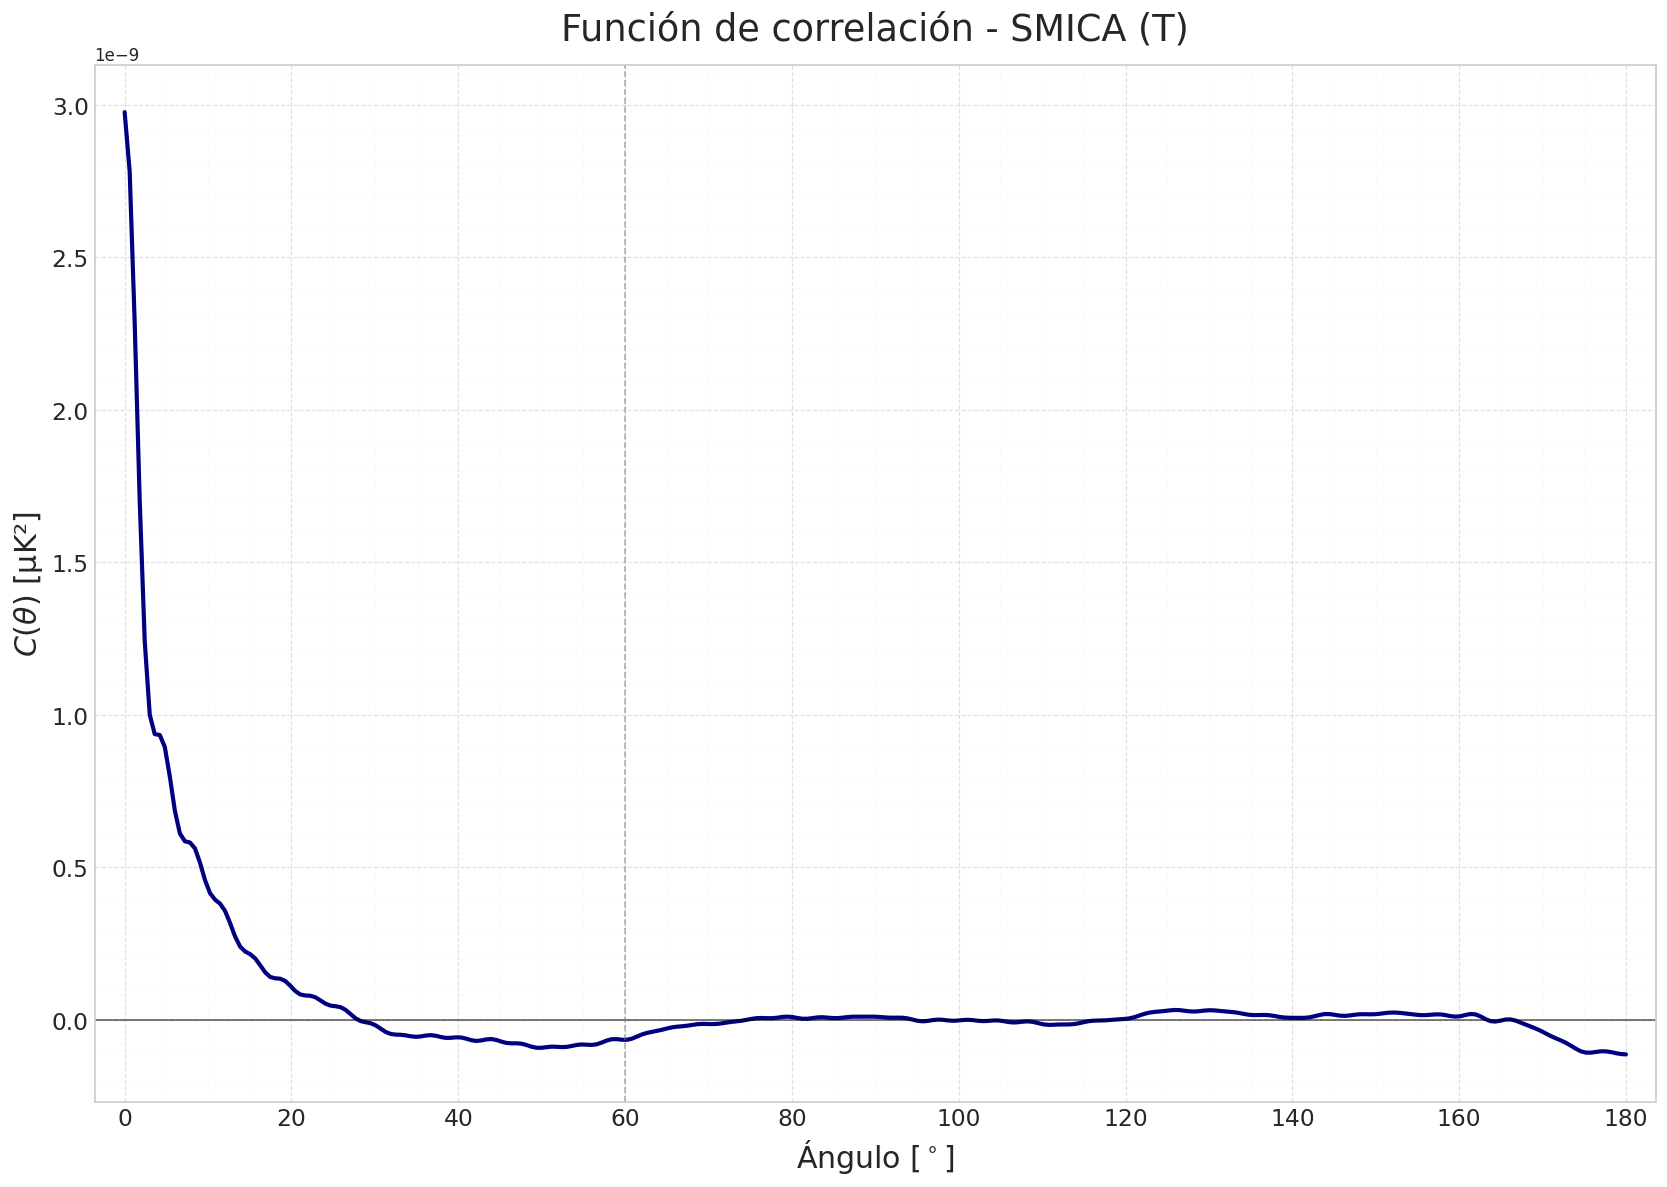

In [34]:
min_ell = 2
max_ell = 100
array_angulos_rad = np.linspace(0, np.pi, 300)
titulo = 'Función de correlación - SMICA (T)'

smica_T_fcorr = FUNCION_CORRELACION_2P(smica_cl_TT, min_ell, max_ell, array_angulos_rad, titulo, mostrar = True)

---

## Comparación de funciones de correlación para distintos mapas

En esta sección vamos a utilizar la función de correlación que hemos programado antes, incluyendo distintos mapas a la vez de forma que podamos compararlos todos en la misma gráfica. Para ello, cargamos los mapas escritos en coeficientes $a_{lm}$.

In [11]:
# SMICA
smica_cl_TT = hp.alm2cl(smica_T_alm)
smica_cl_EE = hp.alm2cl(smica_E_alm)
smica_cl_BB = hp.alm2cl(smica_B_alm)
smica_cl_EB = hp.alm2cl(smica_E_alm, smica_B_alm)

# COMMANDER
commander_cl_TT = hp.alm2cl(commander_T_alm)
commander_cl_EE = hp.alm2cl(commander_E_alm)
commander_cl_BB = hp.alm2cl(commander_B_alm)
commander_cl_EB = hp.alm2cl(commander_E_alm, commander_B_alm)

# NILC
nilc_cl_TT = hp.alm2cl(nilc_T_alm)
nilc_cl_EE = hp.alm2cl(nilc_E_alm)
nilc_cl_BB = hp.alm2cl(nilc_B_alm)
nilc_cl_EB = hp.alm2cl(nilc_E_alm, nilc_B_alm)

# SEVEM
sevem_cl_TT = hp.alm2cl(sevem_T_alm)
sevem_cl_EE = hp.alm2cl(sevem_E_alm)
sevem_cl_BB = hp.alm2cl(sevem_B_alm)
sevem_cl_EB = hp.alm2cl(sevem_E_alm, sevem_B_alm)

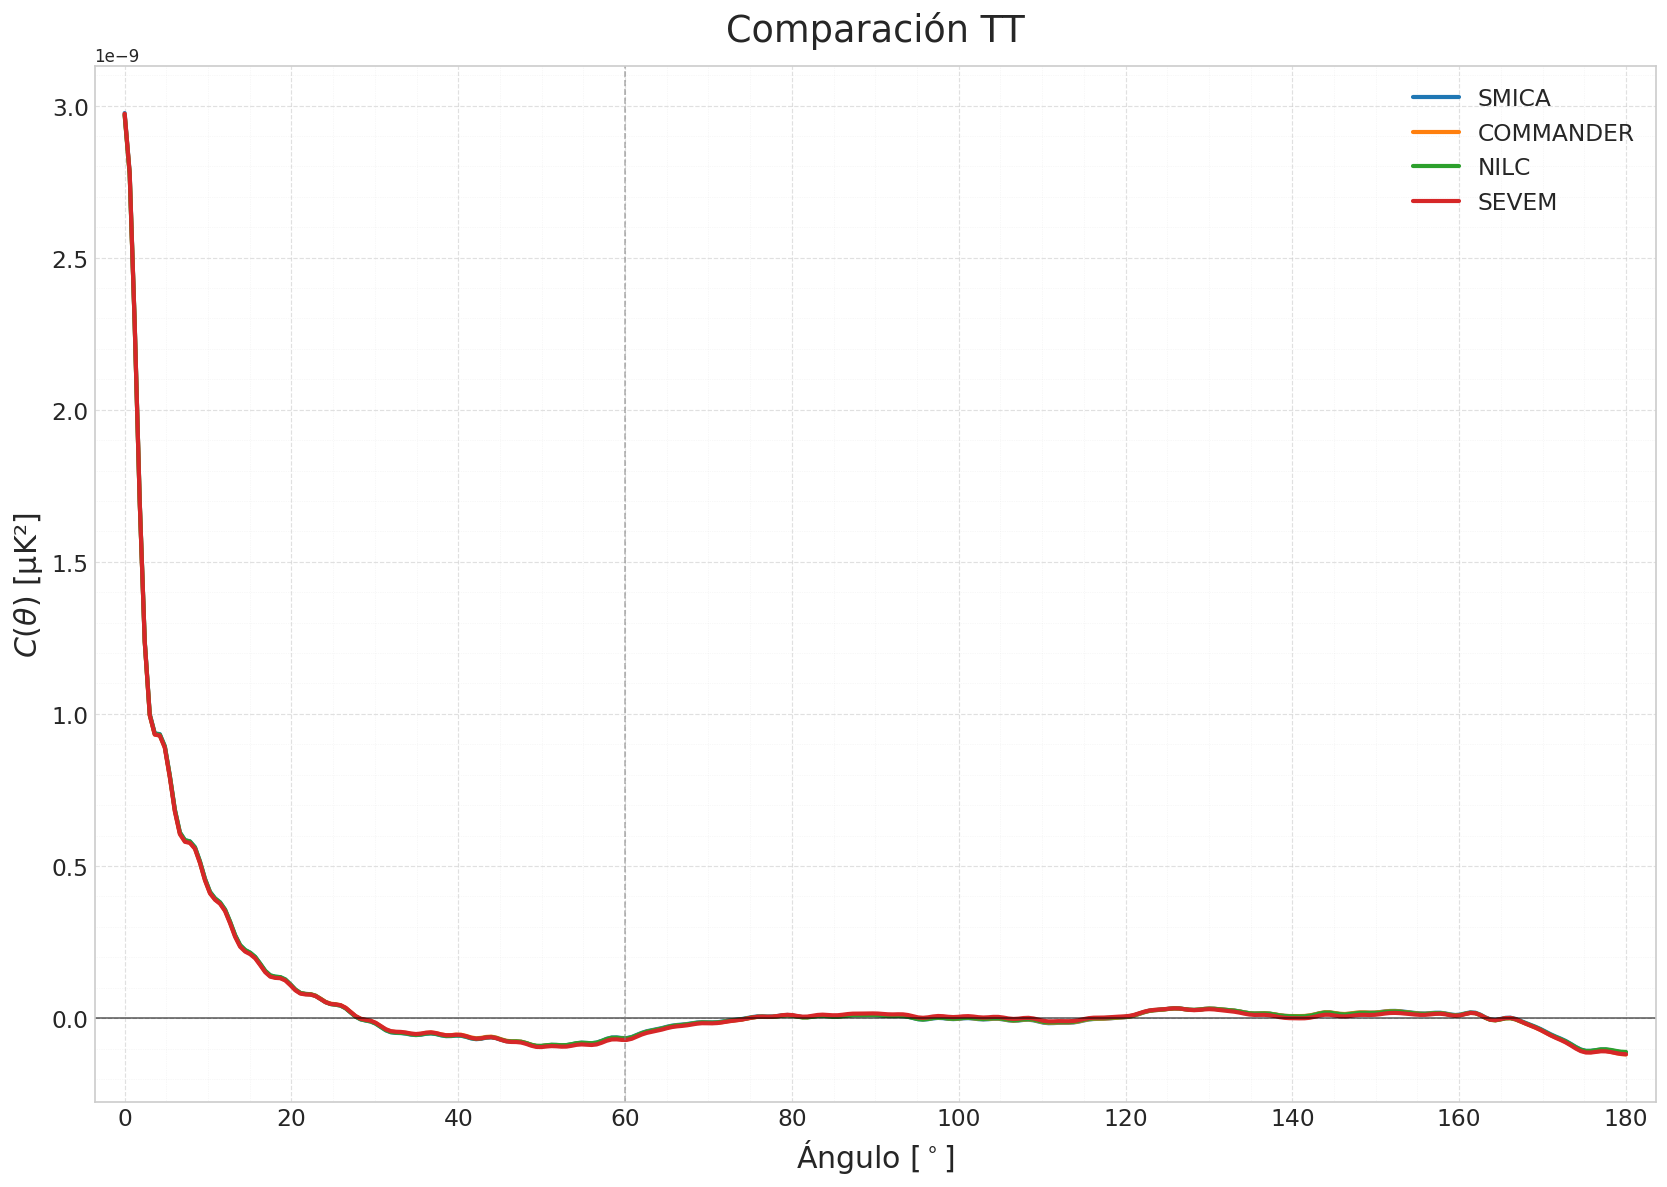

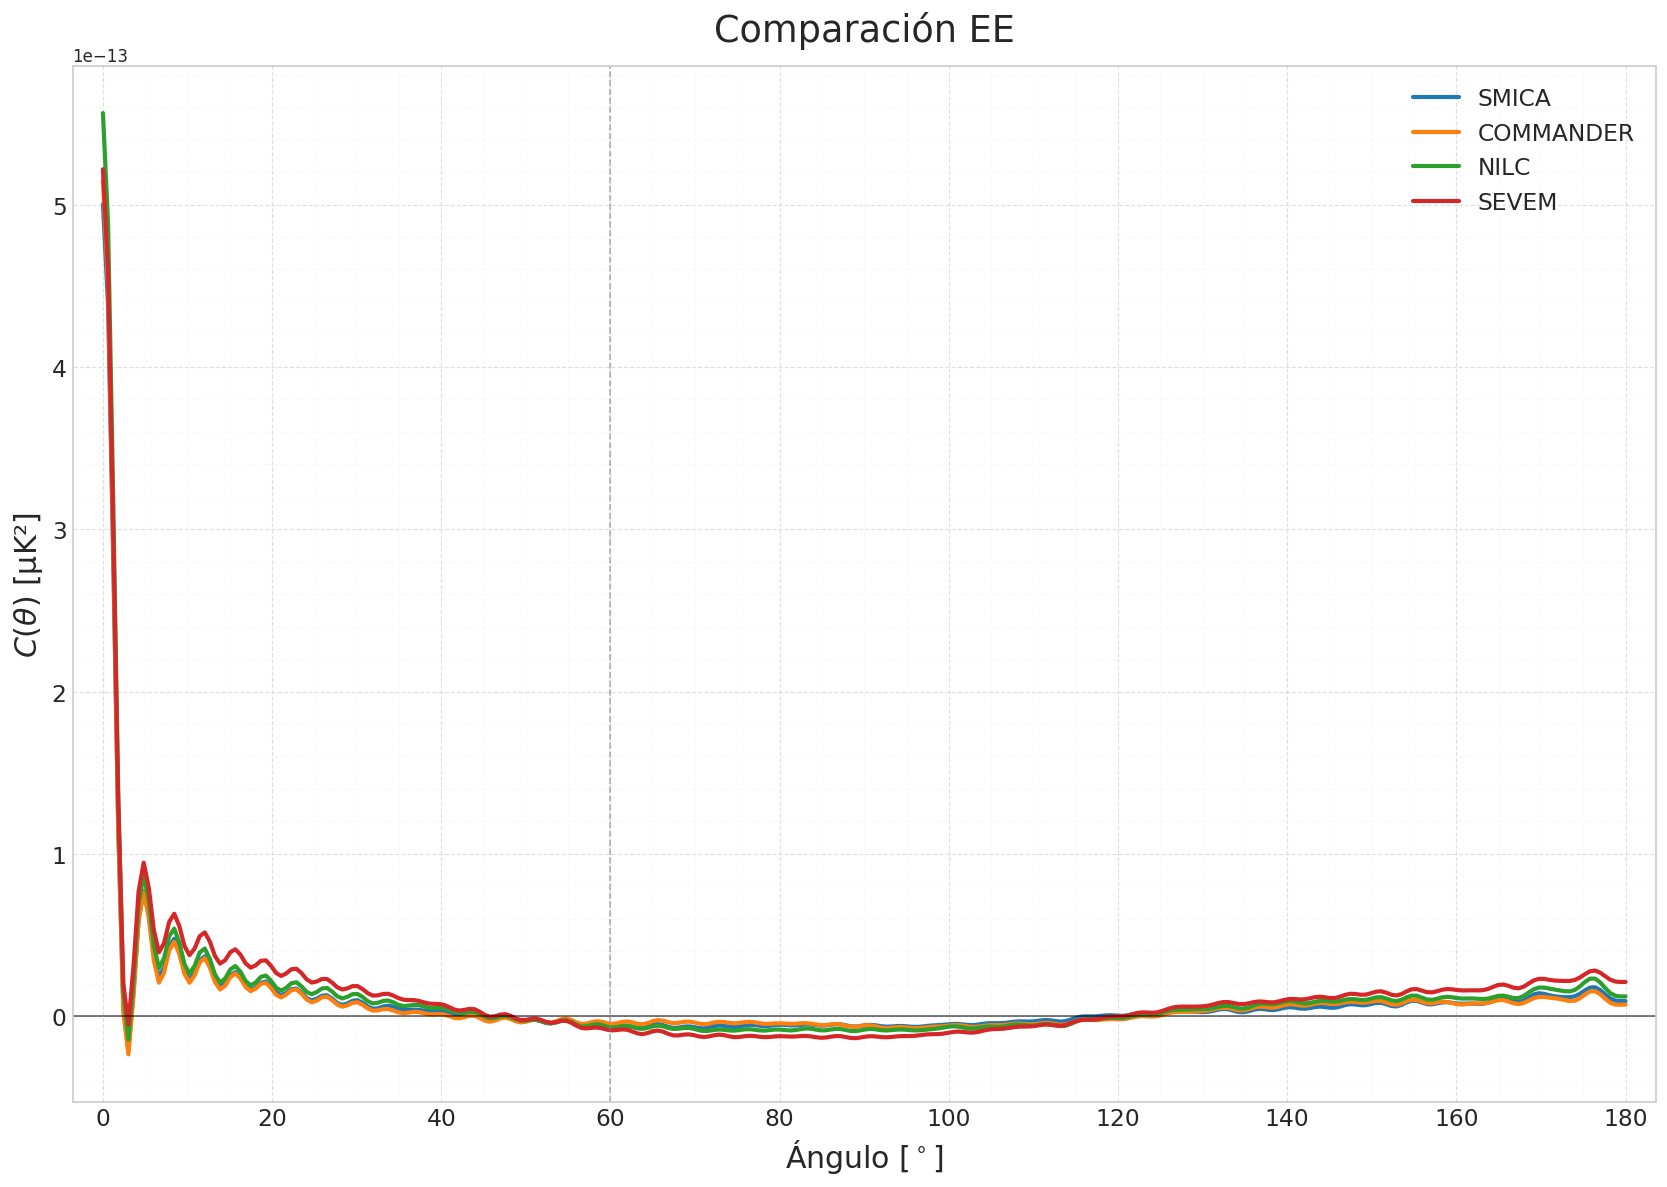

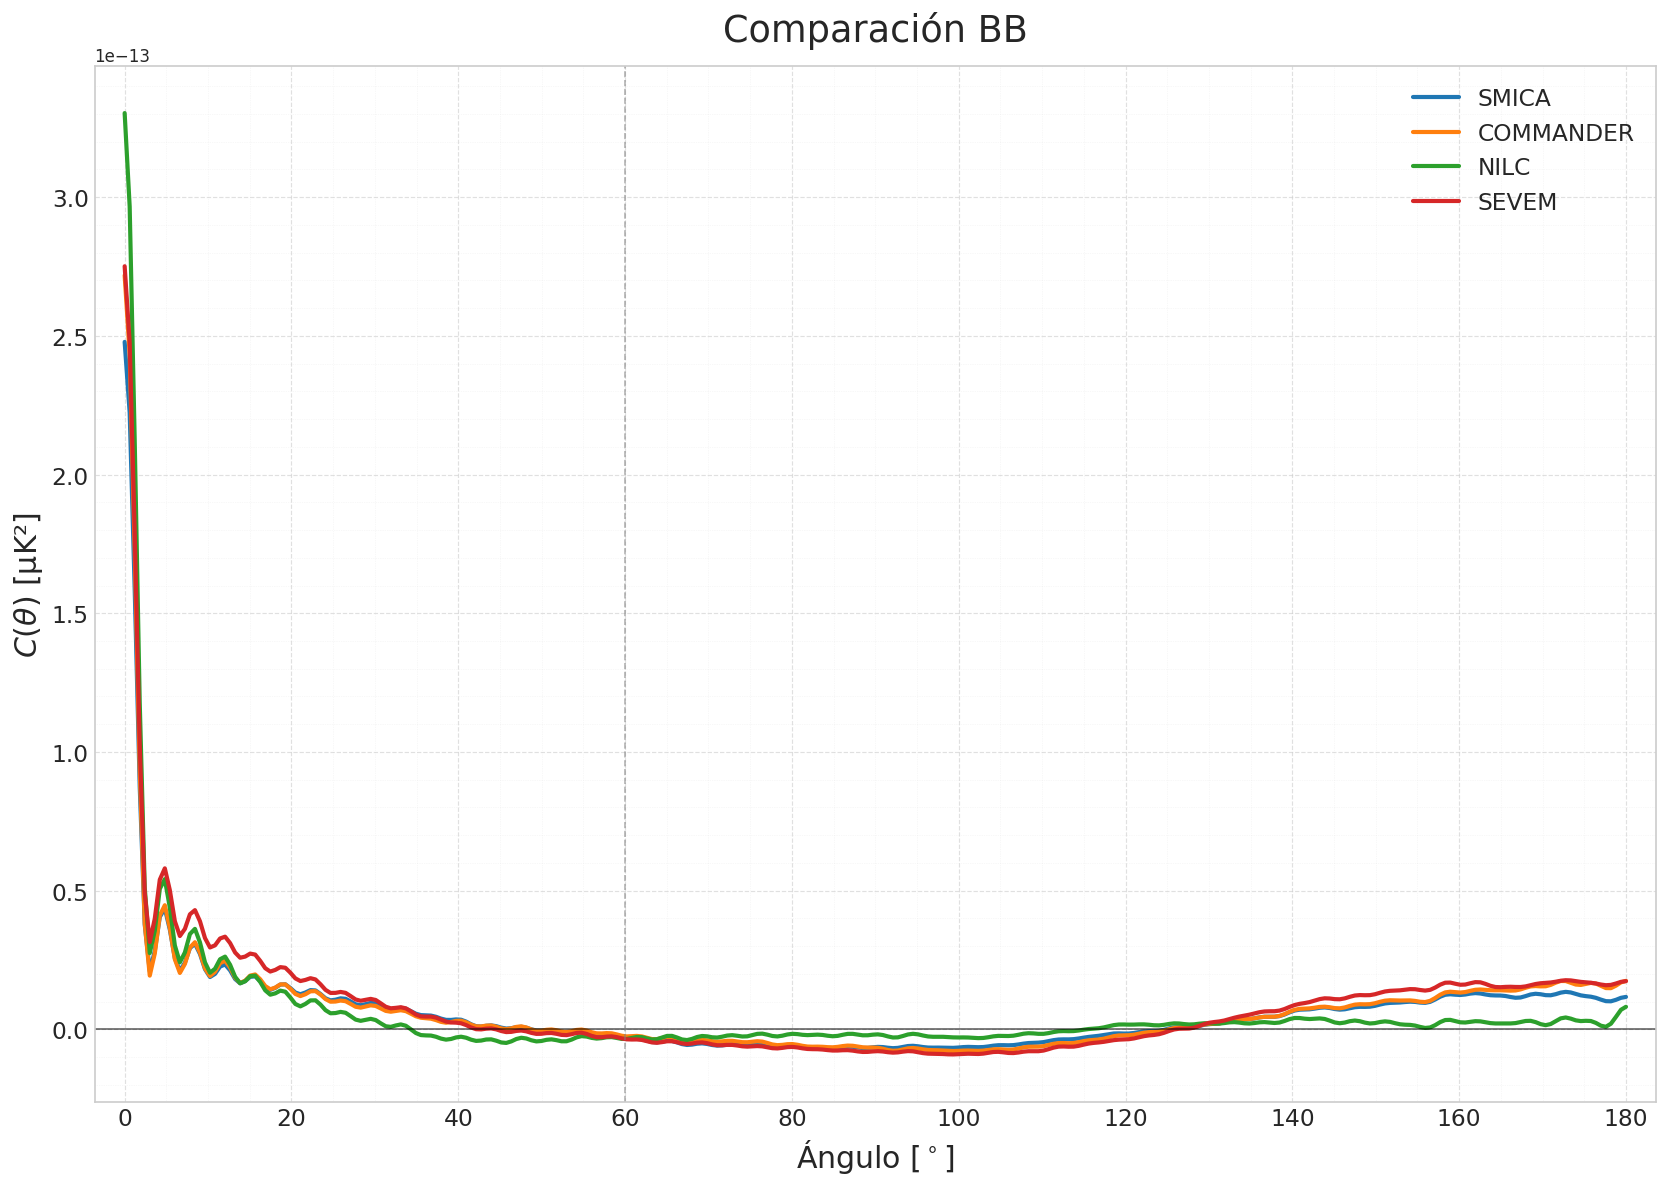

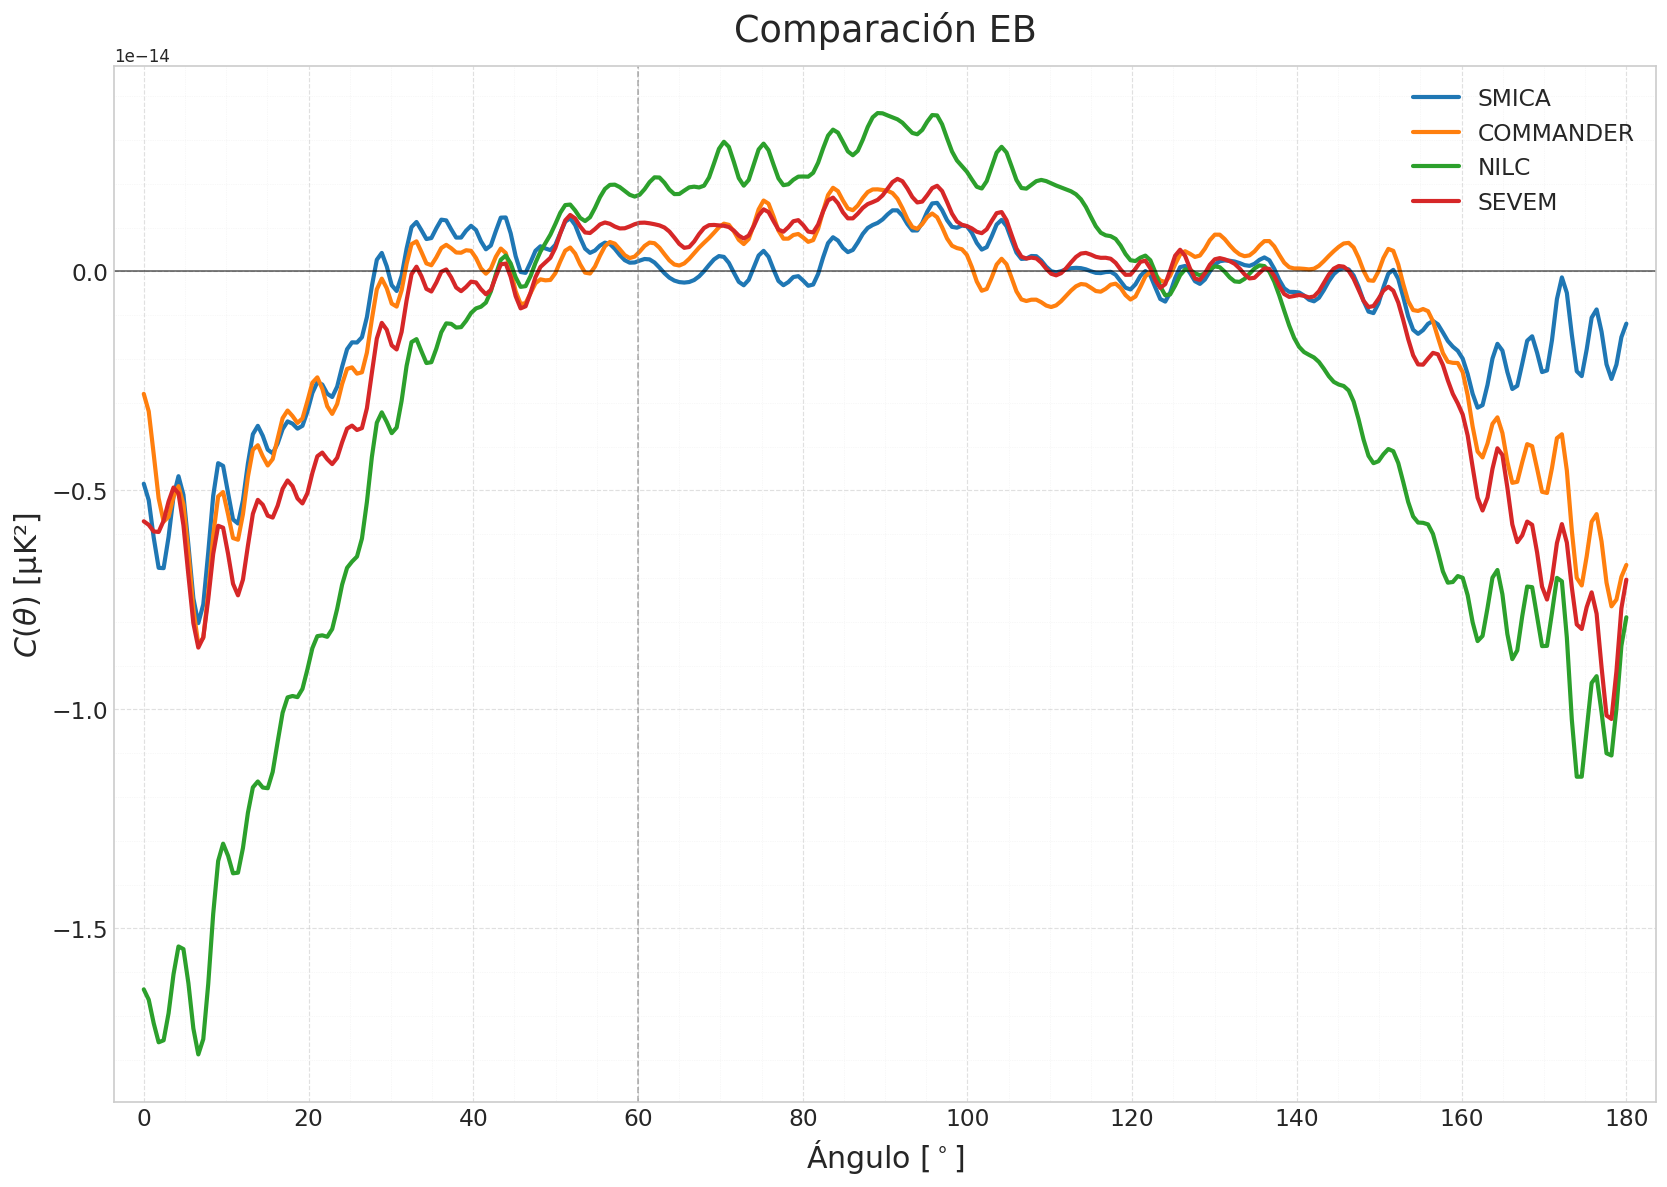

In [13]:
## Indicamos los parámetros que nos van a hacer falta
min_ell = 2
max_ell = 100
array_angulos_rad = np.linspace(0, np.pi, 300)
titulo = 'Función de correlación - SMICA (T)'
# - - - - - - - - - - - - - - - - - - - - - - - - - - #

# Obtenemos la función de correlación de cada coeficiente de cada mapa:

# SMICA
corr_T_smica = FP.FUNCION_CORRELACION_2P(smica_cl_TT, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_E_smica = FP.FUNCION_CORRELACION_2P(smica_cl_EE, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_B_smica = FP.FUNCION_CORRELACION_2P(smica_cl_BB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_EB_smica = FP.FUNCION_CORRELACION_2P(smica_cl_EB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)

# COMMANDER
corr_T_commander = FP.FUNCION_CORRELACION_2P(commander_cl_TT, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_E_commander = FP.FUNCION_CORRELACION_2P(commander_cl_EE, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_B_commander = FP.FUNCION_CORRELACION_2P(commander_cl_BB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_EB_commander = FP.FUNCION_CORRELACION_2P(commander_cl_EB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)

# NILC
corr_T_nilc = FP.FUNCION_CORRELACION_2P(nilc_cl_TT, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_E_nilc = FP.FUNCION_CORRELACION_2P(nilc_cl_EE, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_B_nilc = FP.FUNCION_CORRELACION_2P(nilc_cl_BB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_EB_nilc = FP.FUNCION_CORRELACION_2P(nilc_cl_EB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)

# SEVEM
corr_T_sevem = FP.FUNCION_CORRELACION_2P(sevem_cl_TT, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_E_sevem = FP.FUNCION_CORRELACION_2P(sevem_cl_EE, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_B_sevem = FP.FUNCION_CORRELACION_2P(sevem_cl_BB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)
corr_EB_sevem = FP.FUNCION_CORRELACION_2P(sevem_cl_EB, min_ell, max_ell, array_angulos_rad, titulo, mostrar=False)

# Creamos una lista con las correlaicones de los mapas que queremos comparar
lista_corr_TT = [corr_T_smica, corr_T_commander, corr_T_nilc, corr_T_sevem]
lista_corr_EE = [corr_E_smica, corr_E_commander, corr_E_nilc, corr_E_sevem]
lista_corr_BB = [corr_B_smica, corr_B_commander, corr_B_nilc, corr_B_sevem]
lista_corr_EB = [corr_EB_smica, corr_EB_commander, corr_EB_nilc, corr_EB_sevem]

# Finalmente hacemos uso de la siguiente función para obtener los mapas comparativos

lista_nombre_mapa = ["SMICA", "COMMANDER", "NILC", "SEVEM"]
FP.PLOT_COMPARACION_FUNCION_CORRELACION(lista_corr_TT, array_angulos_rad, "Comparación TT", lista_nombre_mapa)
FP.PLOT_COMPARACION_FUNCION_CORRELACION(lista_corr_EE, array_angulos_rad, "Comparación EE", lista_nombre_mapa)
FP.PLOT_COMPARACION_FUNCION_CORRELACION(lista_corr_BB, array_angulos_rad, "Comparación BB", lista_nombre_mapa)
FP.PLOT_COMPARACION_FUNCION_CORRELACION(lista_corr_EB, array_angulos_rad, "Comparación EB", lista_nombre_mapa)
   